In [1]:
import torch 
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict  
from ReportPretraining import ReportClassification
from src.layers.transformer.ATAT import LightCurveTransformer

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [16]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/AUGS/LC/class_baseline_0_augs/'
PATH_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/AUGS/LC/class_baseline_1_augs/'


#FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"

FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

In [5]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier


True True True False
True True True False
Using checkpoint 2976.ckpt
Using checkpoint 2976.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
Dataset Configuration:
• Seed        : 0
• Set Type         : train
• Total Indices    : 24388
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
-    Using sampler
Dataset Configuration:
• Seed        : 0
• Set Type         : validation
• Total Indices    : 6097
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
not using sampler
Dataset Configuration:
• Seed        : 0
• Set Type         : test
• Total Indices    : 7622
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 107.95it/s]


                precision    recall  f1-score   support

           AGN     0.4583    0.3561    0.4008       556
           QSO     0.6090    0.7105    0.6559       570
            EA     0.7981    0.7491    0.7729       570
           YSO     0.5507    0.5133    0.5313       487
          SNIa     0.7024    0.5402    0.6107       485
       CV/Nova     0.6279    0.5906    0.6087       320
          RRLc     0.6379    0.7042    0.6694       578
         RSCVn     0.5000    0.4369    0.4663       444
        Blazar     0.3480    0.3815    0.3640       270
          SNII     0.5585    0.5401    0.5492       274
         EB/EW     0.7090    0.6574    0.6822       578
           LPV     0.8251    0.8052    0.8150       580
           CEP     0.5714    0.5300    0.5500       566
         RRLab     0.7596    0.7113    0.7347       582
Periodic-Other     0.2891    0.4625    0.3558       240
          DSCT     0.4683    0.5592    0.5097       304
         SNIbc     0.1957    0.3140    0.2411  

100%|██████████| 477/477 [00:04<00:00, 108.41it/s]


                precision    recall  f1-score   support

           AGN     0.4576    0.3687    0.4084       556
           QSO     0.6070    0.6719    0.6378       570
            EA     0.8236    0.7211    0.7689       570
           YSO     0.5742    0.5483    0.5609       487
          SNIa     0.7289    0.5711    0.6405       485
       CV/Nova     0.6275    0.6000    0.6134       320
          RRLc     0.6640    0.7111    0.6867       578
         RSCVn     0.4910    0.4932    0.4921       444
        Blazar     0.3439    0.4407    0.3864       270
          SNII     0.6462    0.5000    0.5638       274
         EB/EW     0.7011    0.6696    0.6850       578
           LPV     0.8336    0.7603    0.7953       580
           CEP     0.6103    0.5035    0.5518       566
         RRLab     0.7596    0.7440    0.7517       582
Periodic-Other     0.3099    0.4958    0.3814       240
          DSCT     0.4777    0.5987    0.5314       304
         SNIbc     0.2727    0.4884    0.3500  

<Axes: title={'center': 'ZTF ATAT LC ONLY: test | macro f1: 0.4707'}, xlabel='Predicted label', ylabel='True label'>

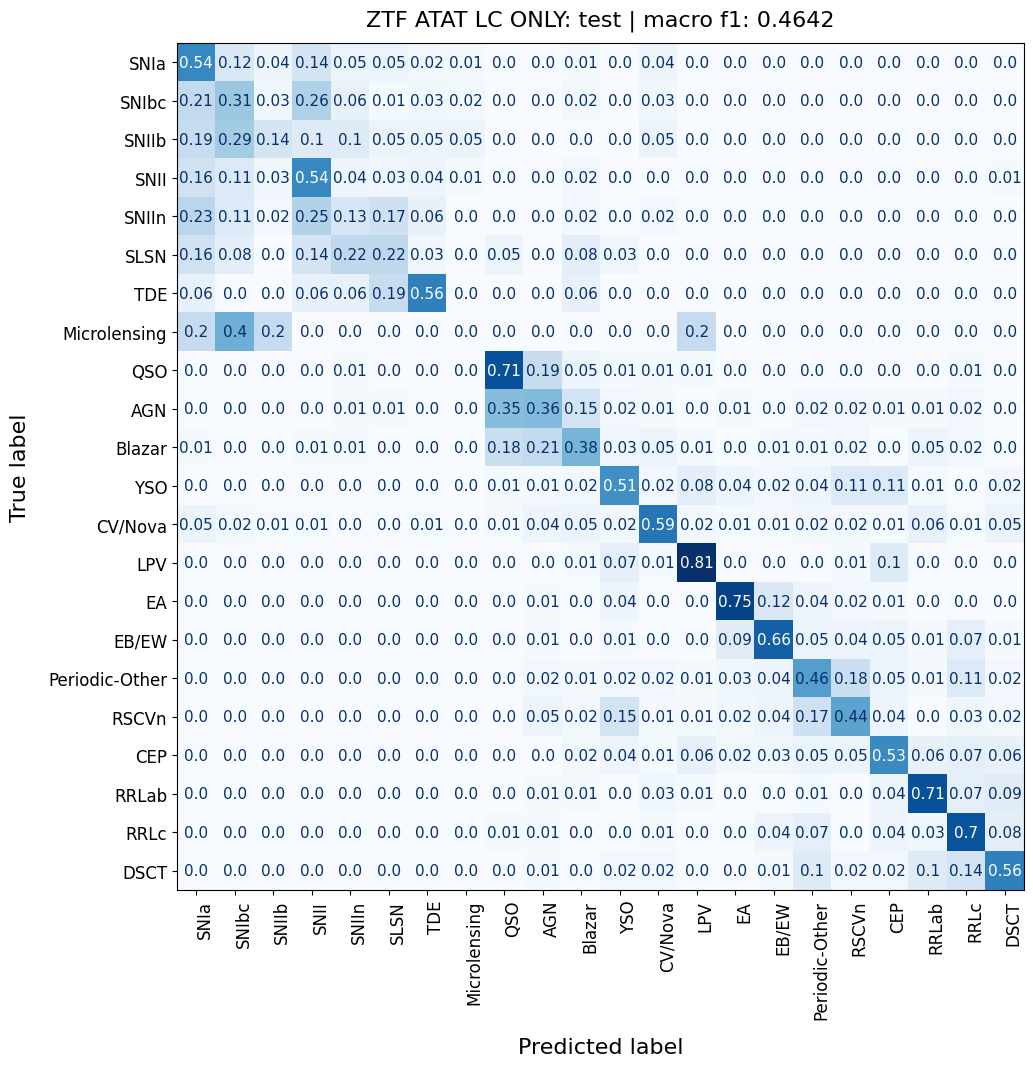

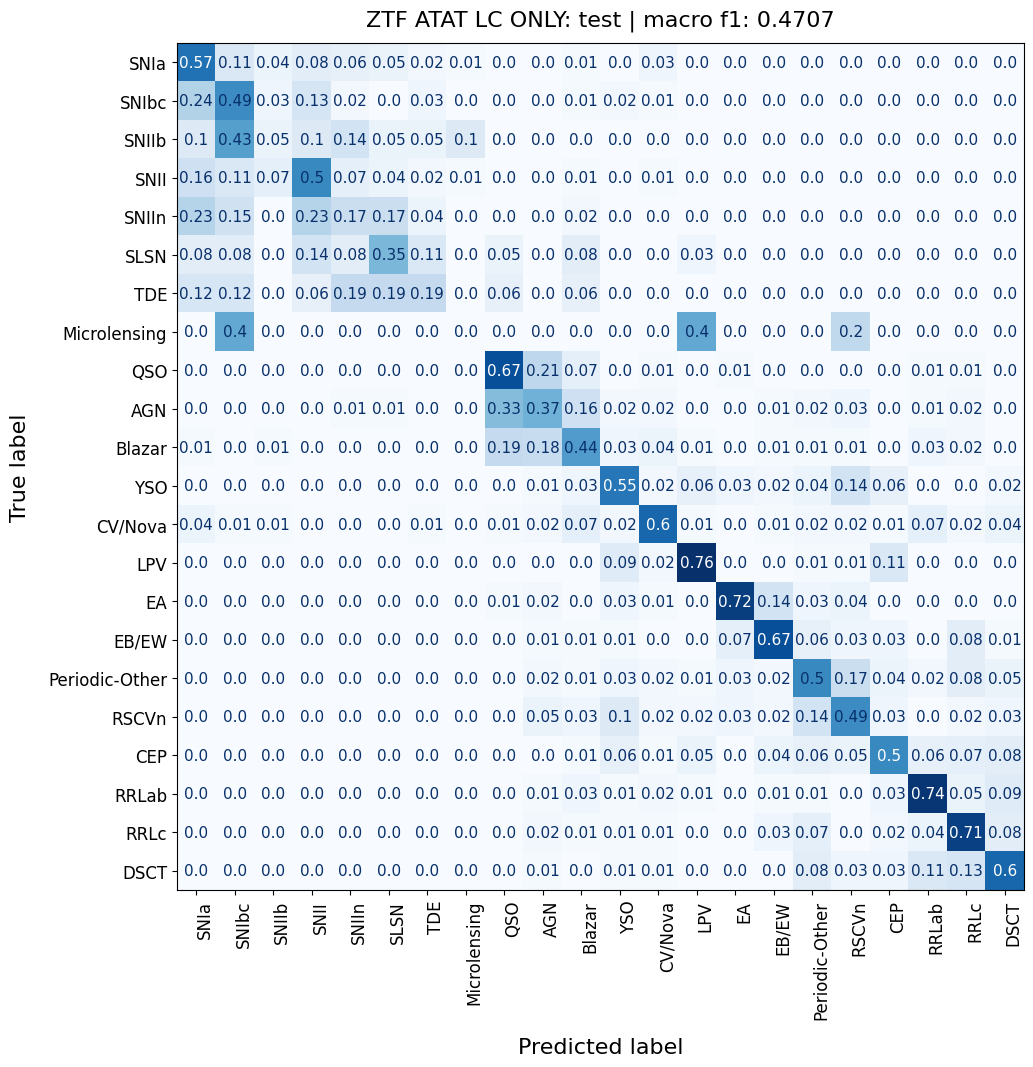

In [17]:
test = InitClassifier(path_to_config_yaml=PATH_1, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)



test = InitClassifier(path_to_config_yaml=PATH_2, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)


True True True False
True True True False
Using checkpoint 2976.ckpt
Using checkpoint 2976.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
Dataset Configuration:
• Seed        : 0
• Set Type         : train
• Total Indices    : 24388
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
-    Using sampler
Dataset Configuration:
• Seed        : 0
• Set Type         : validation
• Total Indices    : 6097
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
not using sampler
Dataset Configuration:
• Seed        : 0
• Set Type         : test
• Total Indices    : 7622
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
device set to cuda:0


 21%|██▏       | 102/477 [00:01<00:03, 112.29it/s]

100%|██████████| 477/477 [00:04<00:00, 104.64it/s]


True True True False
True True True False
Using checkpoint 2376.ckpt
Using checkpoint 2376.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
Dataset Configuration:
• Seed        : 1
• Set Type         : train
• Total Indices    : 24388
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
-    Using sampler
Dataset Configuration:
• Seed        : 1
• Set Type         : validation
• Total Indices    : 6097
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
not using sampler
Dataset Configuration:
• Seed        : 1
• Set Type         : test
• Total Indices    : 7622
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 97.35it/s] 


...

100%|██████████| 477/477 [00:04<00:00, 106.66it/s]


True True True False
True True True False
Using checkpoint 3312.ckpt
Using checkpoint 3312.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
Dataset Configuration:
• Seed        : 3
• Set Type         : train
• Total Indices    : 24388
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
-    Using sampler
Dataset Configuration:
• Seed        : 3
• Set Type         : validation
• Total Indices    : 6097
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
not using sampler
Dataset Configuration:
• Seed        : 3
• Set Type         : test
• Total Indices    : 7622
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 108.02it/s]


True True True False
True True True False
Using checkpoint 2880.ckpt
Using checkpoint 2880.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
Dataset Configuration:
• Seed        : 4
• Set Type         : train
• Total Indices    : 24388
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
-    Using sampler
Dataset Configuration:
• Seed        : 4
• Set Type         : validation
• Total Indices    : 6097
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
not using sampler
Dataset Configuration:
• Seed        : 4
• Set Type         : test
• Total Indices    : 7622
• Light Curves     : ✓
• Metadata         : ✗
• Features         : ✗
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 109.43it/s]


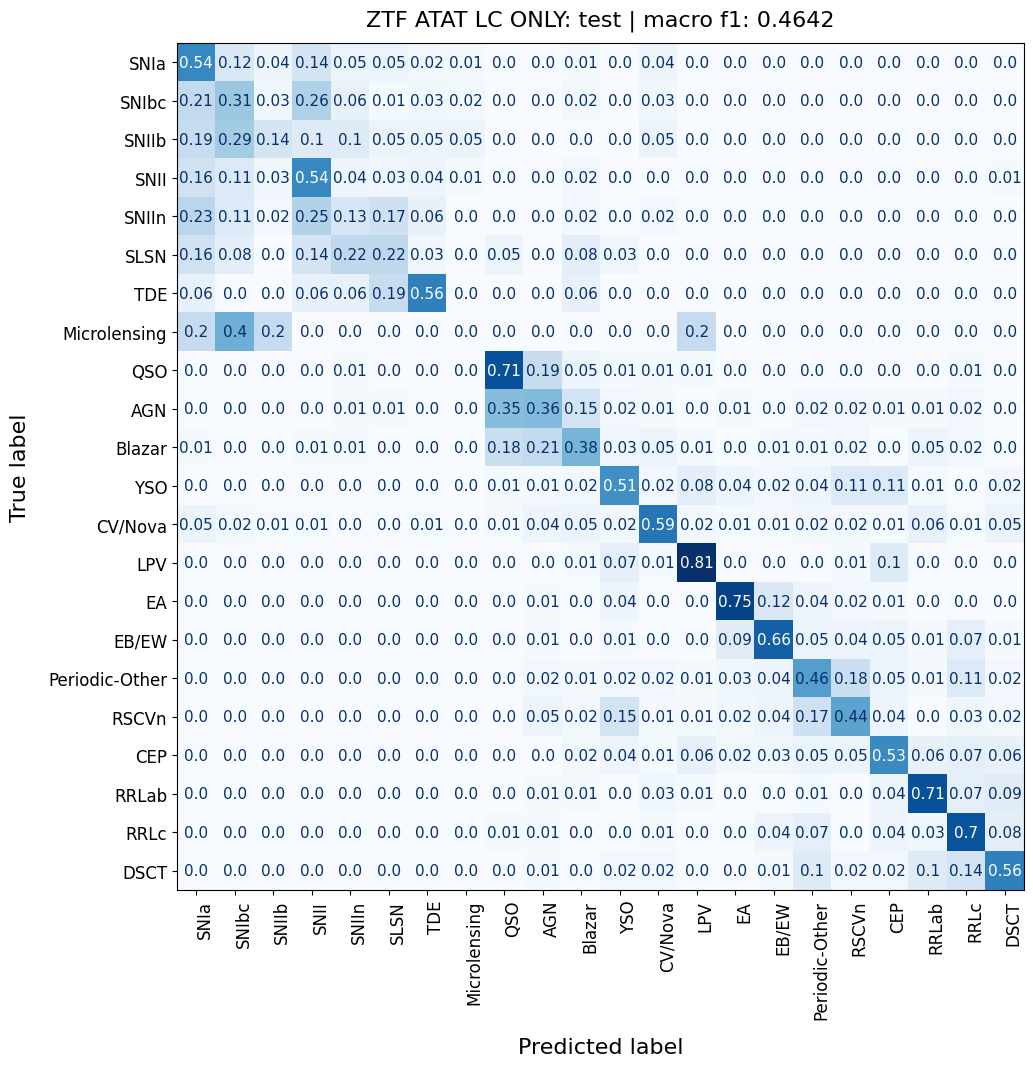

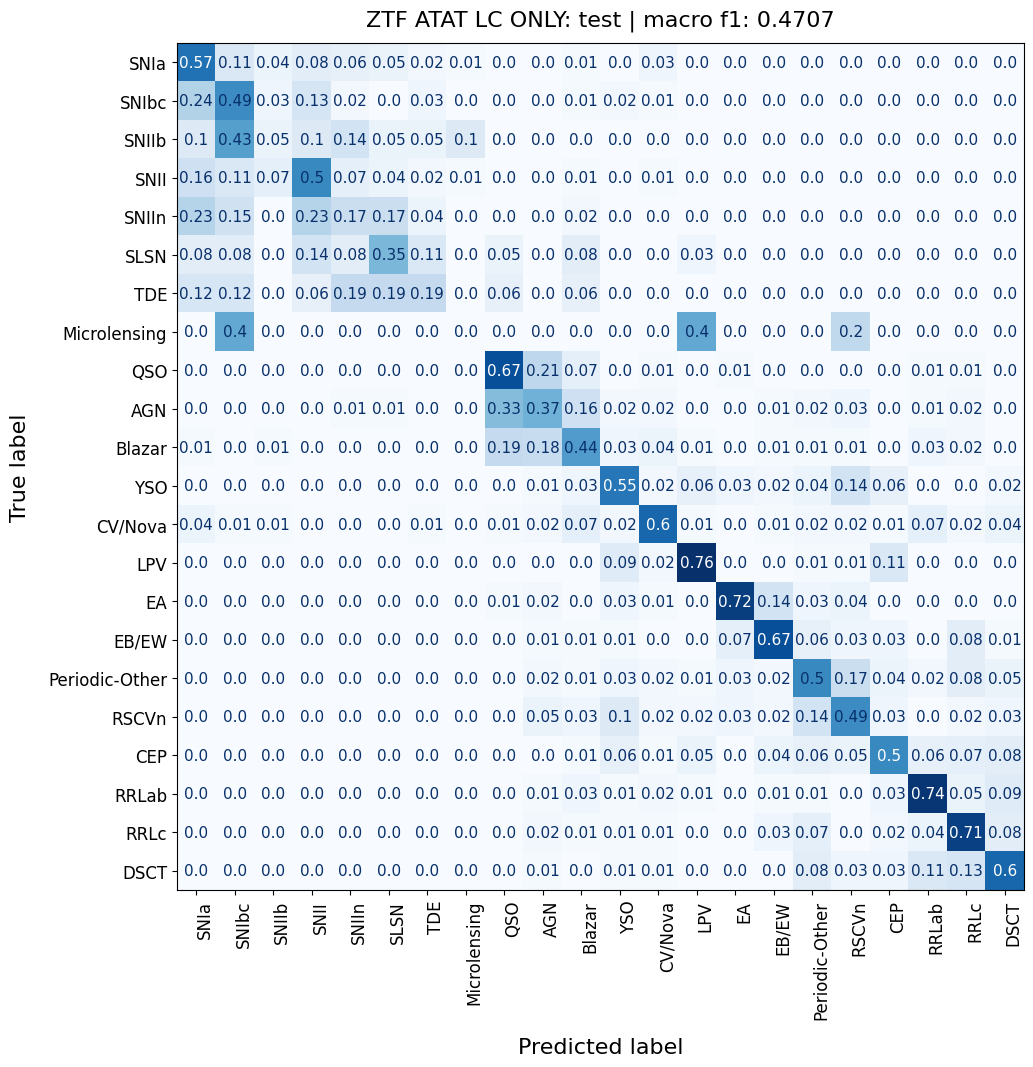

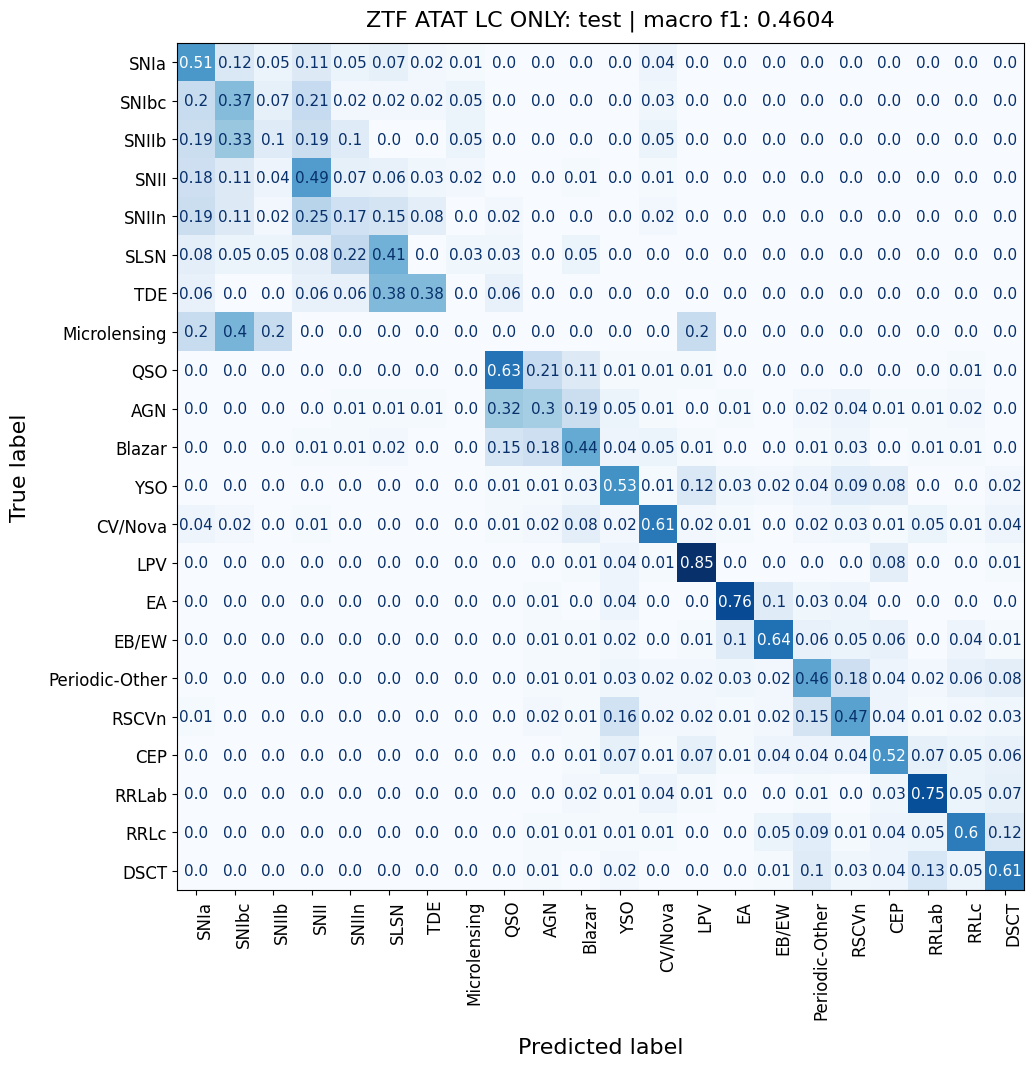

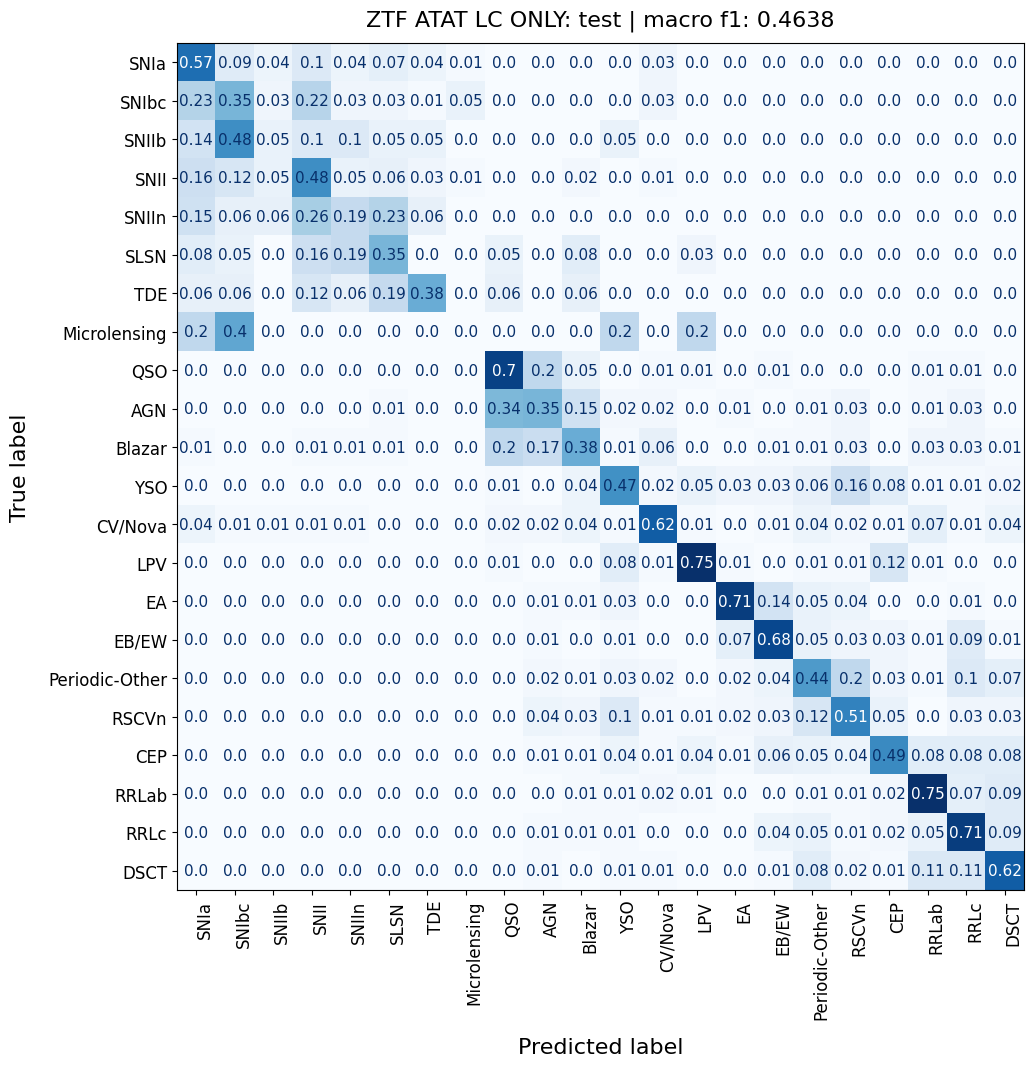

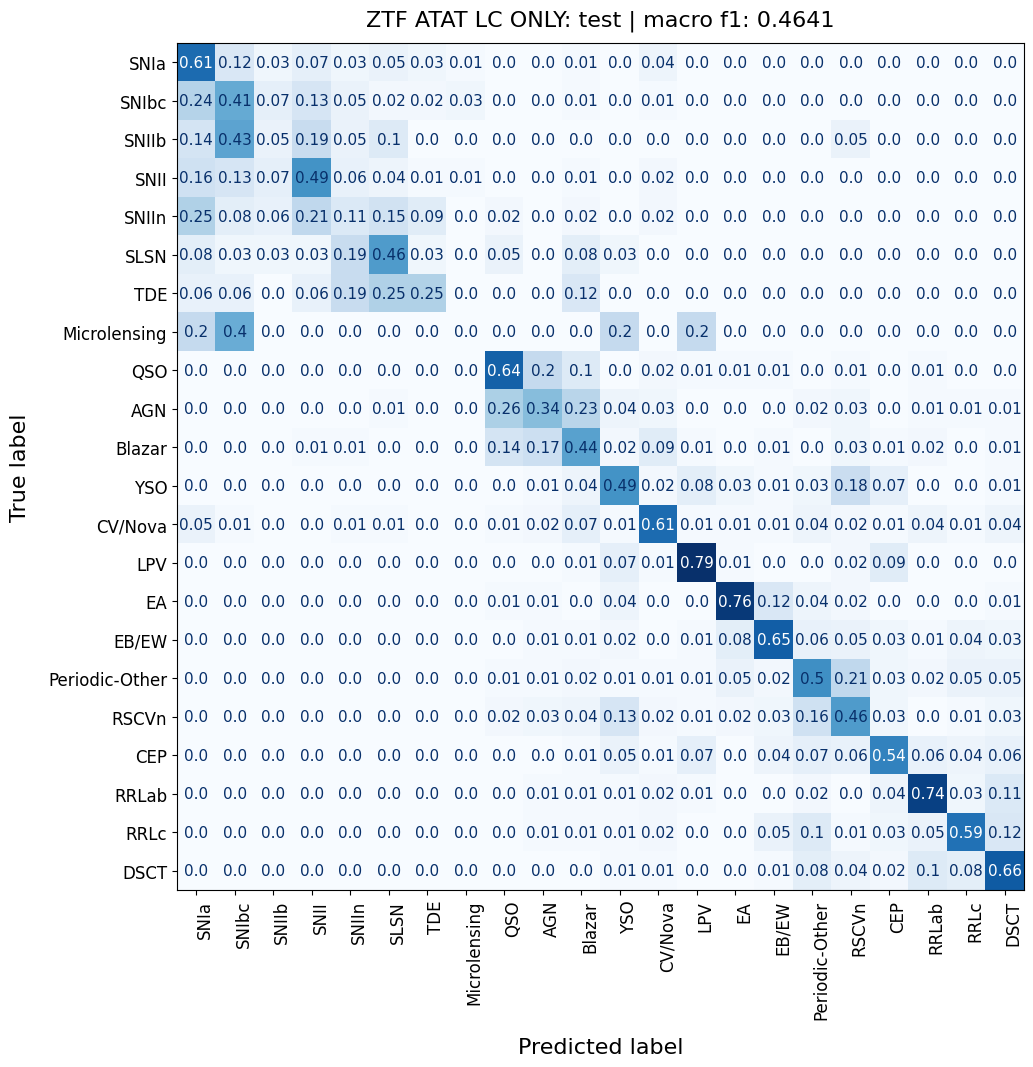

In [21]:
import pandas as pd

reports = []
for i in range(5):
    PATH = f'/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/AUGS/LC/class_baseline_{i}_augs/'
    test = InitClassifier(path_to_config_yaml=PATH, 
                        model= LightCurveTransformer, 
                        classifier = MultimodalClassifier,
                        use_lc = True,
                        arg_key='lc')
    backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
    classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
    test.load_backbone_weights(backbone_od)
    test.load_classifier_weights(classifier_od)
    test.args.datamodule.val_use_sampler = False
    dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
    from sklearn.metrics import classification_report
    val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
    report = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
    reports.append(report)
    test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)


    

def summarize_classification_reports(reports):
    """
    Given a list of sklearn classification_report dictionaries (with output_dict=True),
    compute the mean and standard deviation across them and return a formatted string report.
    """
    # Convert each report to a DataFrame and collect them
    df_list = [pd.DataFrame(r).transpose() for r in reports]
    
    # Align all DataFrames, using outer join to include all possible labels
    all_labels = sorted(set().union(*[df.index for df in df_list]))
    df_list = [df.reindex(all_labels) for df in df_list]
    
    # Combine and group by label
    combined = pd.concat(df_list).groupby(level=0)
    
    # Compute mean and std
    mean_df = combined.mean()
    std_df = combined.std()

    # Format the output string
    report_str = ""
    metrics = ['precision', 'recall', 'f1-score']

    for label in mean_df.index:
        if label == 'accuracy':
            # Accuracy is a single float, stored in the "precision" column
            acc_mean = mean_df.loc[label].get('precision', float('nan'))
            acc_std = std_df.loc[label].get('precision', float('nan'))
            report_str += f"{label:>12}  {acc_mean:.2f} ± {acc_std:.2f}\n"
        else:
            values = []
            for metric in metrics:
                mean_val = mean_df.loc[label].get(metric, float('nan'))
                std_val = std_df.loc[label].get(metric, float('nan'))
                values.append(f"{mean_val:.2f} ± {std_val:.2f}")
            support = mean_df.loc[label].get('support', float('nan'))
            report_str += f"{label:>12}  " + "  ".join(values) + f"  {int(support):>5}\n"

    return report_str




In [23]:
print(len(reports))
print(summarize_classification_reports(reports))

5
         AGN  0.46 ± 0.02  0.34 ± 0.03  0.39 ± 0.02    556
      Blazar  0.33 ± 0.03  0.41 ± 0.03  0.37 ± 0.01    270
         CEP  0.60 ± 0.02  0.52 ± 0.02  0.56 ± 0.01    566
     CV/Nova  0.63 ± 0.04  0.61 ± 0.01  0.62 ± 0.02    320
        DSCT  0.47 ± 0.01  0.61 ± 0.04  0.53 ± 0.01    304
          EA  0.81 ± 0.01  0.74 ± 0.02  0.77 ± 0.01    570
       EB/EW  0.70 ± 0.02  0.66 ± 0.02  0.68 ± 0.00    578
         LPV  0.82 ± 0.03  0.79 ± 0.04  0.81 ± 0.01    580
Microlensing  0.00 ± 0.00  0.00 ± 0.00  0.00 ± 0.00      5
Periodic-Other  0.29 ± 0.01  0.47 ± 0.02  0.36 ± 0.01    240
         QSO  0.61 ± 0.02  0.67 ± 0.04  0.64 ± 0.02    570
       RRLab  0.75 ± 0.01  0.74 ± 0.02  0.74 ± 0.01    582
        RRLc  0.68 ± 0.06  0.66 ± 0.06  0.67 ± 0.02    578
       RSCVn  0.48 ± 0.03  0.47 ± 0.03  0.47 ± 0.02    444
        SLSN  0.18 ± 0.04  0.36 ± 0.09  0.23 ± 0.05     37
        SNII  0.59 ± 0.05  0.50 ± 0.02  0.54 ± 0.02    274
       SNIIb  0.04 ± 0.03  0.08 ± 0.04  0.05 ± 0.03 

PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/MD/class_baseline/'

Found checkpoint 2208.ckpt
Found checkpoint 2208.ckpt
Loaded backbone weights
LOaded classifier weights
-    Using sampler
not using sampler
device set to cuda:0


100%|██████████| 477/477 [00:06<00:00, 75.20it/s]


<Axes: title={'center': 'ZTF ATAT LC ONLY: test | macro f1: 0.441'}, xlabel='Predicted label', ylabel='True label'>

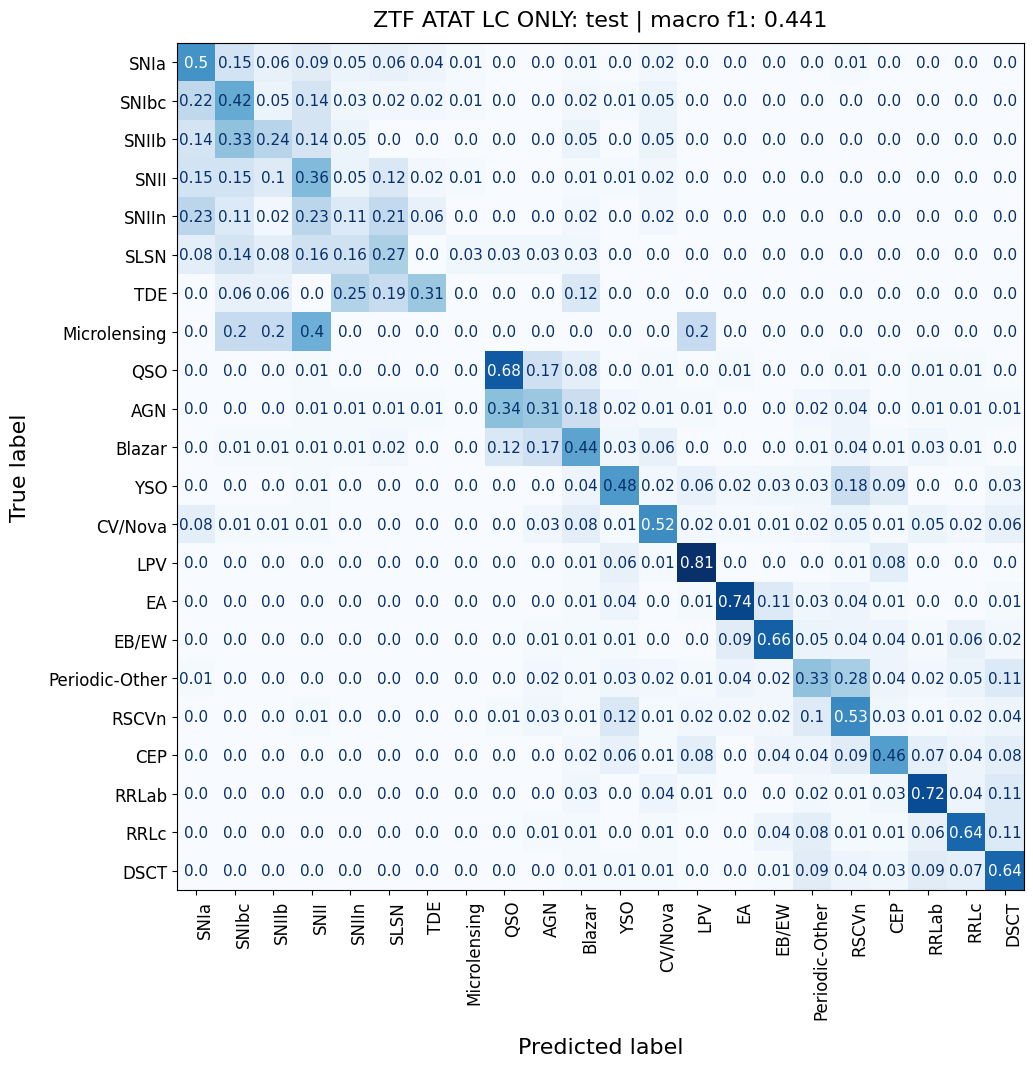

In [9]:
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
test = InitClassifier(path_to_config_yaml=PATH_2, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

In [10]:
import pandas as pd
val_preds.shape
#
df = pd.DataFrame(val_preds)
df['target'] = val_true


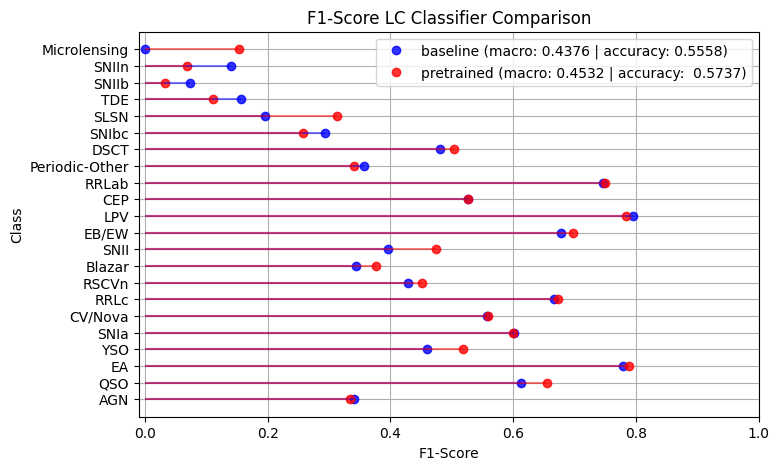

baseline f1 mean:
trans 0.23224881029435107
stoch 0.46289153752643275
per 0.6060381944964748
pretrained f1 mean:
trans 0.24183006433424292
stoch 0.475818318705032
per 0.6093936034098664


In [ ]:
import pandas as pd
import numpy as np

def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [6]:
asdfas

NameError: name 'asdfas' is not defined

In [ ]:
from ReportPretraining import InitDataLoader, InitClassifier
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.transformer.ATAT import TabularTransformer

test = InitClassifier(path_to_config_yaml=PATH_2, 
                    model= TabularTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = False,
                    use_tab = True,
                    arg_key='tab')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_lc', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.validation_dataset, DEVICE)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type='validation', taxonomy = ZTF_TAXONOMY)


ImportError: cannot import name 'InitDataLoader' from 'ReportPretraining' (/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/ReportPretraining.py)

In [12]:
 
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.exploringtools.InitCombinator import InitCombinator
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import TabularTransformer, LightCurveTransformer


PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC_MD_FEAT/baseline_1_combine_logits/'

DEVICE = 'cuda:0'
test = InitCombinator(path_to_config_yaml=PATH, 
                    lc_model= LightCurveTransformer, 
                    tab_model= TabularTransformer, 
                    classifier = MultimodalClassifier,
                    classifier_args={'use_lc':True,'use_tab':True, 'use_mix':True},
                    arg_key='tab', 
                    device = DEVICE)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)



Found checkpoint 4608.ckpt
Found checkpoint 4608.ckpt
Loaded backbone weights
Loaded backbone weights
Found checkpoint 4608.ckpt
Loaded backbone weights
-    Using sampler
not using sampler


KeyboardInterrupt: 

In [ ]:
adsfadf

In [ ]:
import pandas as pd
import numpy as np

def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
        print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report1,report2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

NameError: name 'ljlkj' is not defined

In [ ]:
'''
import numpy as np
import pandas as pd
probs, target = test_1.predict_probs()

review = pd.DataFrame({'is_correct':abs(np.argmax(probs, axis = -1) - target)  == 0,'target':target })
display(review)
def subset_df(subset):

    print(len(subset))

    import h5py
    with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
        flux_incorrect  = f.get('flux')[subset]
        target_incorrect = f.get('labels')[subset]
    print(flux_incorrect.shape)
    dict_ = {value:key for key, value in ZTF_TAXONOMY().items()}
    df = pd.DataFrame({'obs_count':np.count_nonzero(flux_incorrect, axis = (1,2)), 'target':target_incorrect.astype(int)})
    df['target'] = df['target'].map(dict_)
    df = df.groupby('target').aggregate({'obs_count':list})
    df['incorrect_count'] =  df.obs_count.apply(lambda x: len(x))#.reset_index()
    df['mean'] = df['obs_count'].apply(lambda x: np.mean(x).round(2))
    df['std'] = df['obs_count'].apply(lambda x: np.std(x).round(2))
    df = df.sort_values('incorrect_count', ascending = False)
    return df

subset_df(subset = review.query('is_correct == False').index.tolist())
subset_df(subset = review.query('is_correct == True').index.tolist())
'''

In [ ]:

def plot_f1(data_dict, taxonomy):

    f1 = []
    for key,value in data_dict.items():
        if key in taxonomy().keys():
            print(key,value)
            f1.append(value['f1-score'])
    print(f1)

    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a dataframe
    df = pd.DataFrame({'group':taxonomy().keys(), 'values':f1 })
    
    # Reorder it based on the values
    ordered_df = df#.sort_values(by='values')
    my_range=range(1,len(df.index)+1)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
    plt.plot(ordered_df['values'].values, my_range, "o")
    
    # Add titles and axis names
    plt.yticks(my_range, ordered_df['group'])
    plt.title("F1-Score For Each Class", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)

    plt.grid('on')
    # Show the plot
    plt.show()

In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [ ]:
adfadf

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device(DEVICE))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = DEVICE)  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = DEVICE) for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

modl is not sample dependent